<a href="https://colab.research.google.com/github/hlapin/AHA-Topics/blob/main/Diaspora_Inscriptions_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapping Geographical Movement from Ancient Jewish Diasopora Inscriptions?

Inscriptions by Jews from the ancient Mediterranean number between one and two thousand, and come from over two hundred sites. The project here is to ask whether we can model migration patterns from the Eastern to the Western Mediterranean on the basis of inscription data. The project uses data from [ORBIS: The Standford Geospatial Network Model of the Roman World](https://https://orbis.stanford.edu/) to calculate movement along the Roman road system.   
Allowing for considerable uncertainty, there is a clear westward tendency for the appearance of inscriptions over time. Whether this documents the actual movement of people (as I assume here, but cannot prove), the chronology of Jewish adoption of epigraphic practices, or otherwise invisible processes is a question still to be dealt with.   
After importing and cleaning the data and constructing a network graph, this notebook illustrates the following:   
* Describing and visualizing distribution
* Comparing with the distribution of Greek and Latin inscriptions more generally
* Mixed effects linear regression on east-to-west axes
* [Heat diffusion model: poor results thus far]
* Correlating first visibility with distance between nodes
* Maping gradient of first-visibility by site as a proxy for geographical movement.

***Some prefatory notes***   
Inscription sites are restricted to diaspora sites.    
Preparatory to this notebook, I have compiled a list of inscriptions (`jewish.csv`) from standard collections, dated according to the collection editors' determinations. For modeling purposes below, I have used editors' (invevitably, often uncertain) dates to determine a not-before and not-after date, and to assign a probability of the inscription deriving from one of the centuries between these dates equally.   
> For example, *JIWE* dates inscriptions from the Roman Catacombs to the third to the fourth century. These inscriptions are given start and end dates of 200 and 399 respectively, with a .5 probability of belonging to the the third centry or to the fourth century.    

Also pre-compiled are the following documents:
* `JewishInscrMapRefs.csv` providing links to Pleiades, orbis IDs when available, and longitude and latitude information
* `inscr_data_mean_dates.csv` Mean dates of inscriptions from collections of Greek and Latin inscriptions (see below) based on not-before, not-after dates
* `inscr_data_binned_density.csv` the distribution of Greek and Latin inscriptions by number  of locations, binned by century.    

To avoid dowload and importing errors I am using local copies of the orbis files data files:
* `orbisv2_github_sites_extended.csv`
* `orbis_edges_0514.csv`

In [ ]:
# Dependencies
import time
import pandas as pd
import geopandas as gpd
import matplotlib as mpl ## ?? do these both need to be imported?
import matplotlib.pyplot as plt ## ??
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import requests
import random
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import haversine_distances
from itertools import combinations
from scipy.stats import spearmanr, kendalltau, pearsonr, mannwhitneyu
from itertools import combinations
import networkx as nx
from scipy.linalg import expm
from collections import defaultdict

# Inscriptions and Orbis Data

## Get data

In [ ]:
df_jewish = pd.read_csv("jewish.csv", encoding='cp1252')
df_jewish.drop(columns=['Item', 'Start', 'End','Comments','Date'],inplace=True)
df_jewish

,Grouping,Region,Sub-Region,Place,pre II,II,III,IV,V,VI,VII,VIII,unc,not before,not after
0,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
1,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
2,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
3,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
4,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650,Asia Minor: Central,Asia Minor,Lycaonia,Gdanmaa,0.00,0.00,0.00,1.00,0.0,0.0,0.0,0.0,0.0,300,400
1651,Asia Minor: Central,Asia Minor,Lycaonia,Gdanmaa,0.00,0.00,0.00,1.00,0.0,0.0,0.0,0.0,0.0,300,400
1652,Asia Minor: Central,Asia Minor,Lycaonia,Iconium,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,#VALUE!,#VALUE!
1653,Asia Minor: Central,Asia Minor,Asia,Kos,0.25,0.25,0.25,0.25,0.0,0.0,0.0,0.0,0.0,0,399


In [ ]:
# add a weighted date column
century_cols = df_jewish.columns[4:12]
century_dates = [50, 150, 250, 350, 450, 550, 650, 750] # take midpoint of century

df_jewish['weighted_date'] = df_jewish[century_cols].values @ century_dates
# @ operator: matrix multiplication
# equivalent to using np.matmult(A, B)

# variance Var(date) sum total variance for each century date
df_jewish['Var_date'] = (
    df_jewish[century_cols]
    .mul((century_dates - df_jewish['weighted_date'].values[:, None]) ** 2)
    .sum(axis=1)
)
# `None` in values[:, None] (equivalent to np.newaxis) adds an axis
# makes shape of century_dates || weighted date values

Retain only inscriptions that have a numerical `not before` (and `not after`) entry.   
records remain

In [ ]:
df_jewish=df_jewish[df_jewish['not before']!='#VALUE!'].copy()

#convert 'object' dtype to integer in screened columns
df_jewish['not before'] = df_jewish['not before'].apply(lambda x: int(x))
df_jewish['not after'] = df_jewish['not after'].apply(lambda x: int(x))

In [ ]:
## upload map refs
df_maprefs = pd.read_csv('JewishInscrMapRefs.csv')
## drop missing coords
df_maprefs.dropna(subset=['lat', 'long'],inplace=True)

In [ ]:
# for later calculation convert lat/long angle  to radian
df_maprefs['long_rad'] = np.radians(df_maprefs['long'])
df_maprefs['lat_rad'] = np.radians(df_maprefs['lat'])

In [ ]:
# set index to idx, retaining column
# drop index name
df_maprefs.set_index('idx', drop=False, inplace=True)
df_maprefs.index.rename(None, inplace=True)
df_maprefs

,idx,Place,id,pleiades_url,pleiades_id,orbis_id,lat,long,long_rad,lat_rad
50155,50155,Dura Europus,90001,https://pleiades.stoa.org/places/893990,893990.0,50155.0,34.747885,40.729854,0.710870,0.606465
90002,90002,Tafas,90002,NaN,NaN,NaN,32.737778,36.068750,0.629518,0.571382
90003,90003,Nawa,90003,https://pleiades.stoa.org/places/678307,678307.0,NaN,32.889163,36.042243,0.629056,0.574024
90004,90004,Philippopolis,90004,https://pleiades.stoa.org/places/678332,678332.0,NaN,32.853765,36.627525,0.639271,0.573406
90005,90005,Damatha,90005,https://pleiades.stoa.org/places/678107,678107.0,NaN,32.951696,36.430435,0.635831,0.575116
...,...,...,...,...,...,...,...,...,...,...
50353,50353,Side,90248,https://pleiades.stoa.org/places/639105,639105.0,50353.0,36.768361,31.392163,0.547897,0.641729
90249,90249,Gdanmaa,90249,https://pleiades.stoa.org/places/619154,619154.0,NaN,38.614766,32.561380,0.568303,0.673955
50202,50202,Iconium,90250,https://pleiades.stoa.org/places/648647,648647.0,50202.0,37.872456,32.492295,0.567098,0.660999
90251,90251,Laodikaia Katakekaumene,90251,https://pleiades.stoa.org/places/619197,619197.0,NaN,38.192186,32.374024,0.565033,0.666579


In [ ]:
# merge map-ref data to inscription data
df_jewish = pd.merge(df_jewish, df_maprefs,on="Place",how="inner")

In [ ]:
## create a locations table that uses data from both tables for mapping and other opperations

## for aggregation, create a dictionary with value 'sum' for numerical
## and 'first' for string
## mean for not before, not after # is this correct approach?
## use this for aggrecation

agg_dict = {'Grouping': 'first',
 'Region': 'first',
 'Sub-Region': 'first',
 'lat' : 'first',
 'long': 'first',
 'pre II': 'sum',
 'II': 'sum',
 'III': 'sum',
 'IV': 'sum',
 'V': 'sum',
 'VI': 'sum',
 'VII': 'sum',
 'VIII': 'sum',
 'unc': 'sum',
 'not before': 'mean',
 'not after': 'mean'}

## group df_jewish by 'Place'

df_locations = df_jewish.groupby('Place').agg(agg_dict).reset_index()
df_locations['mean_date'] = df_locations[['not before','not after']].mean(axis=1)
# df_locations.drop(columns=['not before','not after'],inplace=True)  # drop as not useful after aggregation?

# add idx column to df_locations and set as index
df_locations = df_locations.merge(df_maprefs[['Place','idx', 'long_rad', 'lat_rad']], how='left', on='Place')

# set index colum to idx, remove index name
df_locations.set_index('idx', drop=False, inplace=True)
df_locations.index.rename(None, inplace=True)


# add 'idx' to df_jewish
df_jewish = df_jewish.merge(df_locations[['Place']],
                            on='Place',
                            how='left')

In [ ]:
orbis_edges = pd.read_csv(r'orbis_edges_0514.csv')
# change column names for consistency
# new_columns = ['id', 'gid', 'source', 'target', 'type', 'expense', 'time', 'geometry']
# orbis_edges.columns = new_columns

# NAN check (diagnostic: should be no NaNs)
for col in ['source','target','km','days','expense']:
    orbis_edges[col] = pd.to_numeric(orbis_edges[col], errors='coerce')
    n_nulls = orbis_edges[col].isna().sum()
    if n_nulls:
        print(f"[WARN] {col} has {n_nulls} NaN(s) after coercion — check source data")

# we do not know which direction a migrant is travelling so combine incoming and outgoing
# `pairs` column for grouping
orbis_edges['pairs'] = orbis_edges.apply(
    lambda r: ' '.join(sorted([str(r['source']), str(r['target'])])),
    axis=1
)

# Average numerical data
# Combine edge types as string when not the same, e.g., `upstream, fastdown`
agg_dict = {
    'source': 'first',
    'target': 'first',
    'km': 'mean',
    'days': 'mean',
    'expense': 'mean',
    'type': lambda x: ', '.join(x.unique())  # or .astype(str) if non-string
}

orbis_edges_directed = orbis_edges.copy()
orbis_edges = orbis_edges.groupby('pairs').agg(agg_dict).reset_index()

In [ ]:
orbis_nodes = pd.read_csv(r"orbisv2_github_sites_extended.csv",index_col='id')
# clean up. With updated dataset, should not be necessary
mask = (orbis_nodes['x'] == 0)   | \
       (orbis_nodes['y'] == 0)   | \
       (orbis_nodes['x'].isna()) | \
       (orbis_nodes['y'].isna())


to_drop = orbis_nodes[mask].index.to_list()
orbis_nodes = orbis_nodes[~mask].copy()


# for later calculation convert lat/long angle (columns `x`, `y`) to radian
orbis_nodes['long_rad'] = np.radians(orbis_nodes['x'])
orbis_nodes['lat_rad'] = np.radians(orbis_nodes['y'])

There are inscription sites that are not nodes in the Orbis dataset. To integrate these, for each "non-Orbis" site, I calculate the three closest Orbis sites and add to the Orbis graph those non-Orbis sites and those links.    
For the `expense` column I multiply by average cost/km.

In [ ]:
# extract map refs that do not appear in orbis
not_orbis = df_maprefs.loc[df_maprefs['orbis_id'].isna()].copy()

In [ ]:
# create dist matrix of not_orbis x orbis to find the three closest orbis site
# to not_orbis map refs
# use haversine distance to convert long/lat rad to km

# assisted by claude.ai
EARTH_RADIUS_KM = 6371.0



dist_matrix_not_orbis_km = haversine_distances(
    not_orbis[['lat_rad', 'long_rad']].values,
    orbis_nodes[['lat_rad', 'long_rad']].values
    ) * EARTH_RADIUS_KM



# average of cost per km from orbis edges
costperkm = 0.016320598
distortion = 1.25 # true route lengths are longer than km displacement

dist_matrix_not_orbis_cost = dist_matrix_not_orbis_km * costperkm * distortion


In [ ]:
# Get indices of 3 smallest distances per row
orbis_ids = orbis_nodes.index.values
not_orbis_ids = not_orbis.index.values

# claude.ai, need to understand np.take_along_axis
top3_idx = np.argsort(dist_matrix_not_orbis_cost, axis=1)[:, :3]
top3_cost = np.take_along_axis(dist_matrix_not_orbis_cost, top3_idx, axis=1)
top3_km = np.take_along_axis(dist_matrix_not_orbis_km, top3_idx, axis=1)
top3_ids = orbis_ids[top3_idx]

# Assign back to not_orbis
for i in range(3):
    not_orbis[f'target{i+1}_id'] = top3_ids[:, i]
    not_orbis[f'target{i+1}_cost'] = top3_cost[:, i]
    not_orbis[f'target{i+1}_km'] = top3_km[:, i]


In [ ]:
# nodes not in orbis to add
nodes_to_add = not_orbis[['Place','lat', 'long','lat_rad','long_rad']]
# rename to match orbis columns ## should rename the opposite way
nodes_to_add.columns = ['label', 'y', 'x','lat_rad','long_rad']

# add these nodes to orbis nodes list
orbis_nodes_extended = pd.concat([orbis_nodes, nodes_to_add])

In [ ]:
## append not_orbis pairs to edge list:
# for each inscr (not_orbis) node create edges
# with EACH of the three closest orbis nodes
edge_groups = []
edge_groups_reverse = []
for i in range(1,4):
  to_append = not_orbis[['id',f'target{str(i)}_id',f'target{str(i)}_cost',f'target{str(i)}_km']]
  to_append.columns = ['source', 'target', 'expense', 'km']
  edge_groups.append(to_append)

  # for directed, simply mirror
  to_append_directed = not_orbis[[f'target{str(i)}_id','id',f'target{str(i)}_cost',f'target{str(i)}_km']]
  to_append_directed.columns = ['source', 'target', 'expense', 'km']
  edge_groups_reverse.append(to_append_directed)

edges_to_add = pd.concat(edge_groups)
edges_to_add_reverse = pd.concat(edge_groups_reverse)


orbis_edges_extended = pd.concat([
    orbis_edges[['source','target','expense', 'km']],
    edges_to_add],
    ignore_index=True)
orbis_edges_extended['combined'] = orbis_edges_extended.apply(lambda row: ','.join(map(str, sorted([row['source'], row['target']]))), axis=1)

orbis_edges_directed_extended = pd.concat([
    orbis_edges_directed[['source','target','expense', 'km']],
    edges_to_add,
    edges_to_add_reverse],
    ignore_index=True)

## Graph construction

In [ ]:
# create graph of orbis_edges_extended
G_orbis_extended = nx.from_pandas_edgelist(
    orbis_edges_extended,
    source='source',
    target='target',
    edge_attr=['expense', 'km'],  # Include the 'weight' column as an edge attribute
)

# node attributes
# set id column as key of dict
node_attrs_dict = orbis_nodes_extended.to_dict(orient='index')
# print(node_attrs_dict)

# add nodes
nx.set_node_attributes(G_orbis_extended, node_attrs_dict)

In [ ]:
# as directed graph
#edges
D_orbis_extended = nx.from_pandas_edgelist(
    orbis_edges_directed_extended,
    source='source',
    target='target',
    edge_attr=['expense', 'km'],  # Include the 'weight' column as an edge attribute
    create_using=nx.DiGraph # Specify a directed graph
)

# attributes
nx.set_node_attributes(D_orbis_extended, node_attrs_dict)

## Distance matrixes

For downstream operations, constuct site-to-site distance matrixes based on raw coordinates and on `km` and `expense` data from Orbis

Because of the shape of the Mediterranean, longitude and latitude are "colinear" (on average when we move from East to West, we also move from South to North). We can rotate axes to account for "tilt" in Mediterranean

In [ ]:
orbis_nodes_extended.rename(columns={'label': 'Place', 'x': 'long', 'y': 'lat' }, inplace=True)
coords = orbis_nodes_extended[['long', 'lat']].values

pca = PCA(n_components=2)
rotated = pca.fit_transform(coords)

orbis_nodes_extended['med_axis'] = rotated[:, 0]   # main Mediterranean direction
orbis_nodes_extended['med_orth'] = rotated[:, 1]   # perpendicular

# standardized axes, only really using med_axis_z
orbis_nodes_extended['med_axis_z'] = (
    orbis_nodes_extended['med_axis'] - orbis_nodes_extended['med_axis'].mean()
    ) / orbis_nodes_extended['med_axis'].std()

orbis_nodes_extended['med_orth_z'] = (
    orbis_nodes_extended['med_orth'] - orbis_nodes_extended['med_orth'].mean()
    ) / orbis_nodes_extended['med_axis'].std()

orbis_nodes_extended['idx'] = orbis_nodes_extended.index
rotated_columns = orbis_nodes_extended[['idx','med_axis','med_orth', 'med_axis_z', 'med_orth_z']]
df_jewish = pd.merge(df_jewish,rotated_columns, on='idx')

### Dist matrix on Mediterranean axis (rotated longitude)

In [ ]:
nodes = list(orbis_nodes_extended.index)

n = len(nodes)

D_med_axis = np.full((n, n), np.inf)
np.fill_diagonal(D_med_axis, 0)

for i, j in combinations(nodes, 2):
  if j == i:
    continue # should not happen
  i_coord = orbis_nodes_extended.loc[i, 'med_axis']
  j_coord = orbis_nodes_extended.loc[j, 'med_axis']
  D_med_axis[nodes.index(i),nodes.index(j)] = abs(i_coord - j_coord)
  D_med_axis[nodes.index(j),nodes.index(i)] = abs(i_coord - j_coord) # symmetrical

df_dist_med_axis = pd.DataFrame(D_med_axis, index=nodes, columns=nodes)


### Distance matrices on graph calculatons of unweighted graph (Dijkstra) distance, and distance weighted by `expense` and `km`.

In [ ]:
# optimized using chatGPT

nodes = list(G_orbis_extended.nodes)
node_index = {n: i for i, n in enumerate(nodes)}

# we want a sublist of inscription sites
inscr_sites = df_jewish['idx'].unique()
to_add = [] # nodes on inscription paths to add for inscr subgraph

n = len(nodes)

D = np.full((n, n), np.inf) # unweighted graph distance
D_km = np.full((n, n), np.inf) # weighted on km
D_cost = np.full((n, n), np.inf) # weighed on cost

np.fill_diagonal(D, 0)
np.fill_diagonal(D_km, 0)
np.fill_diagonal(D_cost, 0)

to_add = set()

weights = [
    (None, D),
    ('km', D_km),
    ('expense', D_cost),
]

for weight, M in weights:
    # computes BOTH lengths and paths
    results = dict(nx.all_pairs_dijkstra(G_orbis_extended, weight=weight))

    for u in nodes:
        i = node_index[u]
        lengths, paths = results[u]
        for v, d in lengths.items():

            if v not in node_index:
                continue

            j = node_index[v]

            # only fill upper triangle
            if j < i:
                continue

            M[i, j] = d
            M[j, i] = d

            # collect intermediate nodes only for inscription pairs
            if u in inscr_sites and v in inscr_sites:

                path = paths[v]
                # skip endpoints
                to_add.update(path[1:-1])


df_dist = pd.DataFrame(D, index=nodes, columns=nodes)
df_dist_km = pd.DataFrame(D_km, index=nodes, columns=nodes)
df_dist_cost = pd.DataFrame(D_cost, index=nodes, columns=nodes)

### Distance matrix on asymmetric costs in the Orbis data

In [ ]:
# Asymmetric distance matrix on D_orbis_extended, weighted on 'expense'
# km should be symmetrical


D_cost_asym = np.full((n, n), np.inf)
np.fill_diagonal(D_cost_asym, 0)


# computes BOTH lengths and paths
results = dict(
    nx.all_pairs_dijkstra(
        D_orbis_extended,
        weight='expense'
    )
)

to_add_asym = set()

for u in nodes:

    if u not in results:
        continue
    i = node_index[u]
    lengths, paths = results[u]
    for v, d in lengths.items():
        if v not in node_index:
            continue

        j = node_index[v]

        # directed assignment only
        D_cost_asym[i, j] = d

        # collect intermediate nodes only for inscription pairs
        if u in inscr_sites and v in inscr_sites:

            path = paths[v]

            # skip endpoints
            to_add_asym.update(path[1:-1])

df_dist_cost_asym = pd.DataFrame(D_cost_asym, index=nodes, columns=nodes)

Create subgraphs of inscription-only data: inscription sites and those that appear on shortest paths betweent them.

In [ ]:
# tag inscription sites in an inscr T/F attribute
nx.set_node_attributes(G_orbis_extended, False, "inscr")
attr_update = {n : True for n in inscr_sites}
nx.set_node_attributes(G_orbis_extended, attr_update, "inscr")

# subgraph of all inscr sites and those on shortest paths
# useful?
to_add.update(inscr_sites)
G_inscr = G_orbis_extended.subgraph(to_add).copy()

In [ ]:
# again for directed

nx.set_node_attributes(D_orbis_extended, False, "inscr")
attr_update = {n : True for n in inscr_sites}
nx.set_node_attributes(D_orbis_extended, attr_update, "inscr")

# subgraph of all inscr sites and those on shortest paths
# useful?
to_add.update(to_add_asym) # inscr sites were added to set previusly
D_inscr = D_orbis_extended.subgraph(to_add).copy()

# Distribution

## Jewish Inscriptions

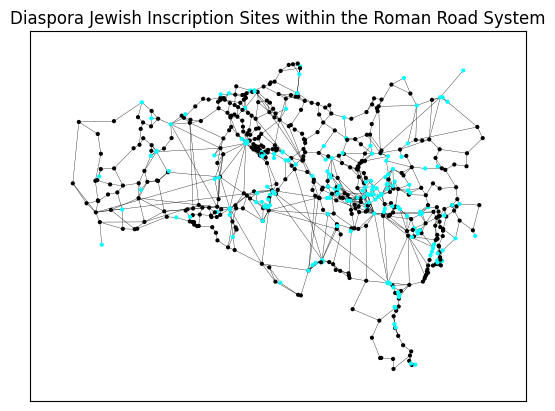

In [ ]:
# draw inscription map
# TODO: add borders layer

# colors to use
colors_dict = {0 : "black", 1 : "cyan"}

pos = dict()
color = []
to_drop = []
for n in G_inscr.nodes:
   node_dict = G_inscr.nodes[n]
   if node_dict.get('x') is None: # drop orbis nodes with no long lat
       # print(n, G_inscr.nodes[n])
       to_drop.append(n)
   else:
       pos[n] = (G_inscr.nodes[n]['x'], G_inscr.nodes[n]['y'])
       if G_inscr.nodes[n]['inscr']==True:
           color.append(1)
       else: color.append(0)

for n in to_drop:
    G_inscr.remove_node(n)

# specify colors:
color = [colors_dict[c] for c in color]

plt.figure()
plt.title('Diaspora Jewish Inscription Sites within the Roman Road System')
nx.draw_networkx(G_inscr, pos, node_size=4, width=0.25,
                 node_color=color, with_labels=False)


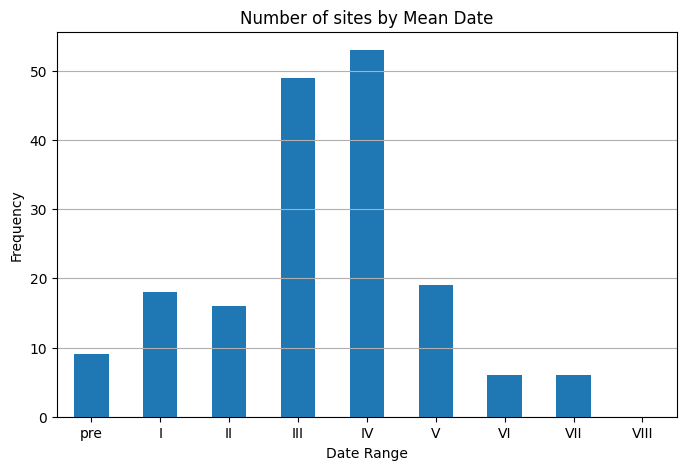

In [ ]:
# plot inscription sites by *location*
# plotting by number will be skewed by high-inscription sites, especially Rome

bins = [-100,0,100,200,300,400,500,600,700,800]
lbls = ['pre','I','II','III','IV','V','VI','VII','VIII']

jewish_to_plot = df_locations[(df_locations['not before']>=-100) & (df_locations['not after']<800)]
jewish_cent_dist = pd.cut(jewish_to_plot['mean_date'],bins=bins,labels=lbls)

counts = jewish_cent_dist.value_counts(sort=False)

# 4. Plot
plt.figure(figsize=(8, 5))
counts.plot(kind='bar',rot=0)#, color='skyblue', edgecolor='black', rot=0)
plt.title('Number of sites by Mean Date')
plt.ylabel('Frequency')
plt.xlabel('Date Range')
plt.grid(axis='y')# , linestyle='--', alpha=0.7)
plt.show()

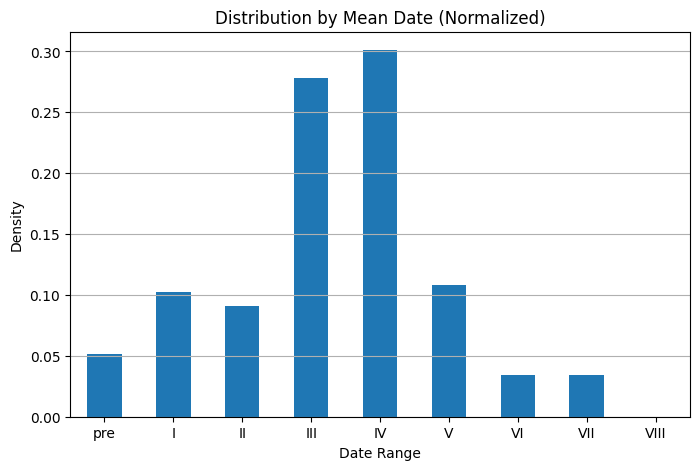

In [ ]:
# normalized/density plot, for comparison with Greek and Latin inscriptions
counts = jewish_cent_dist.value_counts(sort=False,
                                       normalize=True) # for density

plt.figure(figsize=(8, 5))
counts.plot(kind='bar', rot=0)#, color='skyblue', edgecolor='black', rot=0)
plt.title('Distribution by Mean Date (Normalized)')
plt.ylabel('Density')
plt.xlabel('Date Range')
plt.grid(axis='y')# , linestyle='--', alpha=0.7)
plt.show()

### Plot sites by mean weighted date of locations
`not_before`, `not_after`,`mean_date` are already averages by location. Set `century` based on mean date.


In [ ]:
# create century column in df_locations
# bins = [-100,0,100,200,300,400,500,600,700,800]
# lbls = ['pre','I','II','III','IV','V','VI','VII','VIII']
bins = [-100,100,300,600,700]
lbls = ['pre-II','II-III','IV-V','VI-VII']

df_locations['century'] = pd.cut(df_locations['mean_date'],bins=bins,labels=lbls)

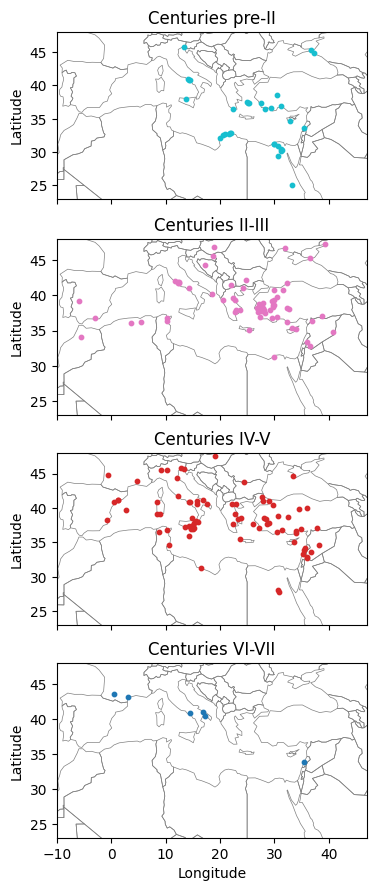

In [ ]:
# chatGPT written
# crop world to Mediterranean
#restrict to mediterranean reigion

# world outline
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

med_bounds = {
    "minx": -10,   # west (Portugal/Morocco)
    "maxx": 47,    # east (Levant) + room for legend
    "miny": 23,    # south (North Africa)
    "maxy": 48     # north (Italy/Balkans)
}

world_med = world.cx[
    med_bounds["minx"]:med_bounds["maxx"],
    med_bounds["miny"]:med_bounds["maxy"]
]

# convert points to GeoDataFrame (WGS84 lon/lat)
gdf = gpd.GeoDataFrame(
    df_locations,
    geometry=gpd.points_from_xy(df_locations['long'], df_locations['lat']),
    crs="EPSG:4326"
)

# colors
cmap = mpl.colormaps['tab10_r']
colors = cmap(np.linspace(0, 1, len(lbls)))

# number of subplots
n = len(lbls)


fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(4, 2.75 * n),
    sharex=True,
    sharey=True
)
fig.subplots_adjust(hspace=0)

# ensure axes is iterable even if n == 1
if n == 1:
    axes = [axes]

for i, cent in enumerate(lbls):
    ax = axes[i]
    ax.set_ylabel("Latitude")

    # country outlinesc
    world_med.plot(
        ax=ax,
        color="none",
        edgecolor="grey",
        linewidth=0.5
    )

    # subset points for this century
    gdf_cent = gdf[gdf["century"] == cent]

    gdf_cent.plot(
        ax=ax,
        markersize=10,
        color=colors[i],
        # alpha=0.5,
        label=cent
    )

    # ax.legend(loc="upper right")

    # rotated PCA axes (same logic as before)
    scale = 20
    direction = [1, 1]

    # if model_rot.params['med_axis'] == abs(model_rot.params['med_axis']):
    #     direction[0] = -1
    # if model_rot.params['med_orth'] == abs(model_rot.params['med_orth']):
    #     direction[1] = -1

    # (actual plotting of axes omitted here since it wasn't in original code)

    ax.set_xlim(med_bounds["minx"], med_bounds["maxx"])
    ax.set_ylim(med_bounds["miny"], med_bounds["maxy"])

    ax.set_title(f"Centuries {cent}")

# shared labels
axes[-1].set_xlabel("Longitude")
# fig.text(0.04, 0.5, "Latitude", va="center", rotation="vertical")

plt.show()



Distribution does not increase only in the Western direction,  but clearly there are more insciptions in the Western Mediterraean in the second through fifth centuries than in the first.
   
Compare [this map published in the 1990s](https://www.pbs.org/wgbh/pages/frontline/shows/religion/maps/jewish.html):   


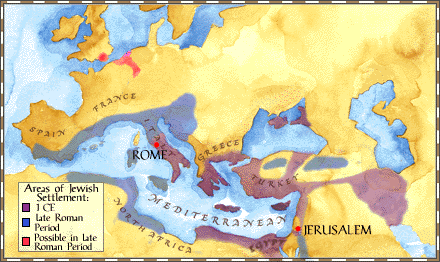

## Greek and Latin Inscriptions   
For recent discussion see:

> Heřmánková, P., Kaše, V., & Sobotkova, A. (2021). Inscriptions as data: digital epigraphy in macro-historical perspective. Journal of Digital History, 1(1). https://doi.org/10.1515/JDH-2021-1004?locatt=label:JDHFULL    

I use the following collections:
* **Greek (IPHI)**: Kaše, Vojtěch et al. 2023. “GIST.” Zenodo. https://doi.org/10.5281/zenodo.10139110.
>The
GIST dataset is primarily based on an online collection of ancient Greek inscriptions published
by the Packard Humanities Institute (PHI) and available via the Ithaca project as I.PHI [15].
A key feature of the dataset is that, wherever available, the spatial and temporal metadata are
expressed in a machine-readable form.    
>Sommerschield, Thea. (2021) 2025. “Sommerschield/Iphi.” Python. https://github.com/sommerschield/iphi.

* **Latin (EDH)** Epigraphic Database Heidelberg,
DOI 10.5281/zenodo.4888167

* **Latin (EDCSx)**: Epigraphic Database Clauss Slaby, https://doi.org/10.5281/zenodo.4888817, deduplicated from EDH as indicated by Heřmánková, et al. 2023  

**Notes:**
* Greek (IPHI) is skewed toward earlier periods. (If I did the calculation correctly, the Jewish inscriptions come from more places in LA than the Greek inscriptions, which is unlikely on the face of it.
* Due to the size of these datasets and the necessary downoad and processing times, I have provided pre-processed extracts for use here.



### Compare Jewish with Greek/Latin

In [ ]:
df_inscr_binned = pd.read_csv('inscr_data_binned_density.csv', index_col=[0])
df_inscr_mean_dates = pd.read_csv('inscr_data_mean_dates.csv', index_col=[0])

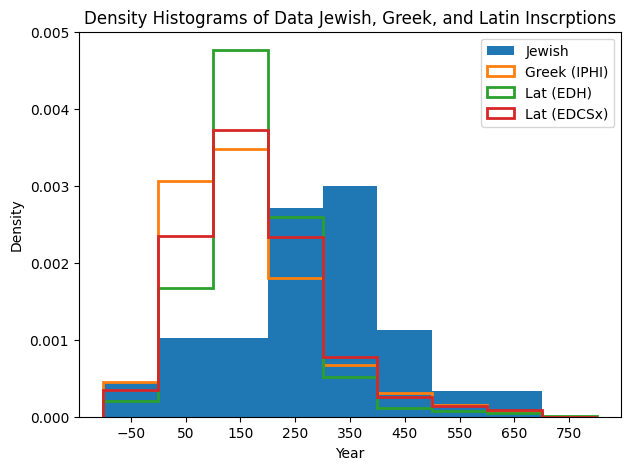

In [ ]:
bins = range(-100,801,100)
plt.figure(figsize=(7, 5))
plt.title('Density Histograms of Data Jewish, Greek, and Latin Inscrptions')
plt.hist(df_inscr_mean_dates['Jewish'], density=True, bins=bins, label='Jewish')
plt.hist(df_inscr_mean_dates['Greek (IPHI)'], density=True,bins=bins, histtype='step', linewidth=2, label='Greek (IPHI)')
plt.hist(df_inscr_mean_dates['Lat (EDH)'],density=True, bins=bins, histtype='step',linewidth=2, label='Lat (EDH)')
plt.hist(df_inscr_mean_dates['Lat (EDCSx)'],density=True, bins=bins, histtype='step', linewidth=2, label='Lat (EDCSx)')
plt.xticks(range(-50,751,100))
plt.xlabel('Year')
plt.ylabel('Density')
plt.legend()
plt.show()


Mann Whitney U

Cliff's delta divides Mann-Whitney by the lengths of the two series being compared, and ranges from 0 to 1

In [ ]:
df_inscr_mean_dates = df_inscr_mean_dates[(df_inscr_mean_dates > -100) & (df_inscr_mean_dates <= 800)].copy()

SeriesA = df_inscr_mean_dates['Jewish'].dropna()
SeriesB = df_inscr_mean_dates['Greek (IPHI)'].dropna()
SeriesC = df_inscr_mean_dates['Lat (EDH)'].dropna()
SeriesD = df_inscr_mean_dates['Lat (EDCSx)'].dropna()

# A vs B
u_ab, p_ab = mannwhitneyu(
    SeriesA,
    SeriesB,
    alternative='two-sided'
)

# A vs C
u_ac, p_ac = mannwhitneyu(
    SeriesA,
    SeriesC,
    alternative='two-sided'
)

# A vs D
u_ad, p_ad = mannwhitneyu(
    SeriesA,
    SeriesD,
    alternative='two-sided'
)

print('Mann-Whitney, Cliff\'s Delta')
print('n. Jewish \t n. Gr-Lat \t\t Mann-Whitney U \t p \t Cliff\'s' )
print(len(SeriesA),
      '\t', len(SeriesB),
      '\t',f"{SeriesA.name} vs {SeriesB.name}:",
      '\t',u_ab,
      '\t',f"{p_ab:.2f}",
      '\t',f"{u_ab/(len(SeriesA)*len(SeriesB)):.2f}")
print(len(SeriesA),
      '\t',len(SeriesC),
      '\t',f"{SeriesA.name} vs {SeriesC.name}:",
      '\t',u_ac,
      '\t',f"{p_ac:.2f}",
      '\t',f"{u_ac/(len(SeriesA)*len(SeriesC)):.2f}")
print(len(SeriesA),
      '\t',len(SeriesD),
      '\t',f"{SeriesA.name} vs {SeriesD.name}:",
      '\t',u_ad,
      '\t', f"{p_ad:.2f}",
      '\t',f"{u_ad/(len(SeriesA)*len(SeriesD)):.2f}")

Mann-Whitney, Cliff's Delta
n. Jewish 	 n. Gr-Lat 		 Mann-Whitney U 	 p 	 Cliff's
177 	 593 	 Jewish vs Greek (IPHI): 	 80713.0 	 0.00 	 0.77
177 	 6808 	 Jewish vs Lat (EDH): 	 919046.0 	 0.00 	 0.76
177 	 5416 	 Jewish vs Lat (EDCSx): 	 714323.5 	 0.00 	 0.75


Box Plot   
The interquartile range of Jewish inscriptions barely overlaps with that of the other inscription sets.    
As with Mann-Whitney, they imply that the distributions are fundamentally different.

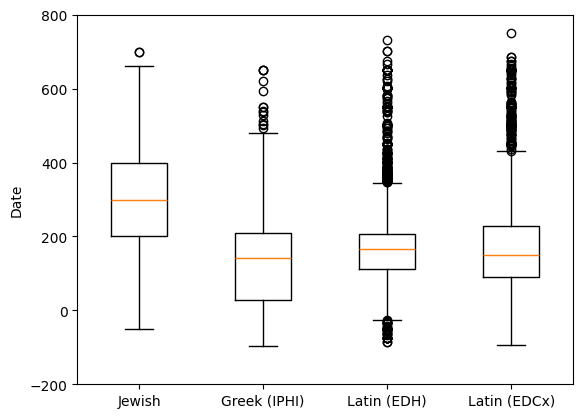

In [ ]:
df_inscr_mean_dates.apply(pd.to_numeric,errors='coerce') # should not be necessary
plt.boxplot([SeriesA, SeriesB, SeriesC, SeriesD],
            tick_labels=["Jewish","Greek (IPHI)", "Latin (EDH)", "Latin (EDCx)"])

plt.ylabel("Date")
plt.yticks(range(-200,801,200))
plt.show()

## Observations
The corpus of "Jewish" inscriptions is for all intents and and purposes a subset of either the Greek or the Latin inscriptions. Nevertheless, they skew considerably later. (In the comparative histogram, the Jewish inscriptions reach there peak two centuries after all of the other comparanda.)    
This skew is statistically significant and interesting, although it is not clear how to interpret it. At a minimum, "exogenous" factors like massive revolts in Palestine, Egypt, Cyrene, and Cyprus, may have suppressed the "expected" number of inscriptions.   
In terms of numbers of inscriptions, the Jewish inscriptions bear some similarity to the distribution of inscriptions in EDCSx, with its disproportionate focus on Rome, but that similarity disappears when we factor only the sites where inscriptions occur.    
There is some similarity with the pattern of the spread of Christian sites as analyzed by Fousek, Jan et al. 2018. “Spatial Constraints on the Diffusion of Religious Innovations: The Case of Early Christianity in the Roman Empire.” Edited by Peter F. Biehl. PLOS ONE 13 (12): e0208744. https://doi.org/10.1371/journal.pone.0208744. Their data examines expansion through the beginning of the fourth century, and does not cover the later periods examined here.    
**Provisionally**: To the extent that Jewish inscription peak in the fourth century and westward spread appears to continue later (against likely demographic trends in the western Mediterranean), I am inclined to see this as at least partly specifically Jewish phenomenon.


# Regressions

* raw (rotated) longitude
* graph (Dijkstra) distance as constructed from Orbis
* kilometer-weighted graph distance as constructed from Orbis
* cost-weighted graph distance as constructed from Orbis, assuming an undirected graph (costs averaged)
* cost-weighted graph distance as constructed from Orbis, assuming a directed graph


**Still to implement here**: Bootstrapping to better model the uncertain dating of the inscriptions.

In [ ]:
# function to calculate for east-west anchors on graph
def east_west_anchors_on_graph(G, weight, site_data, axis):
  """
  Find the most eccentric nodes in G, that are the farthest East and West on axis
  args
    G : incoming graph
    weight: graph attribute to weight dijkstra calculation
    site_data : df with node ids, lat, long, med_axis (rotated long), med_orth (rotated lat)
    axis : axis to use (med_axis is the rotated longitude)
  """
  # get peripheral nodes from weighted graph:
  peripheral = pd.Series(nx.eccentricity(G,weight=weight), name='ecc')
  cutoff = peripheral.quantile(0.75)
  peripheral = peripheral[peripheral > cutoff]
  nodes = site_data.loc[site_data.index.isin(peripheral.index)]

  east_idx, east_coord, east_name = nodes.loc[nodes[axis].idxmax(),['idx',axis,'Place']].values
  west_idx, west_coord, west_name = nodes.loc[nodes[axis].idxmin(),['idx',axis,'Place']].values

  return  (east_idx, east_coord, east_name), (west_idx, west_coord, west_name)

In [ ]:
# function to perform mixed effects linear regression.
# For comparison, between trials, the distance traversed is scaled to a [0,1] scale

# calculate regression on [0,1] scale
def mixed_linear(G, weight, site_data, axis,dist_mtx, east_anchor, west_anchor):
  """
  args
    G : graph (orbis or subgraph)
    weight : graph attribute for distance
    dist_mtx : a pre-calculated distance matrix on raw med_axis, cost, or km
    east_anchor, west_anchor
  """

  # # get anchors
  # anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G,weight,site_data,axis)
  # east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

  axis_metr = dist_mtx[east_anchor]/(dist_mtx[west_anchor] + dist_mtx[east_anchor])
  axis_metr.name = 'axis_metr'

  ### skiping the update of stored data dfs here ###
  to_regress = df_jewish[['Place','idx','weighted_date']].copy()
  to_regress = to_regress.merge(axis_metr,
                                left_on='idx',
                                right_index=True,
                                how='left')


  model_mixed_linear = smf.mixedlm(
      "weighted_date ~ axis_metr",
      to_regress,
      groups=to_regress["Place"]
  ).fit()
  print(model_mixed_linear.summary())

## Mixed effects model
TODO requires explication   
TODO parameterize and rewrite as functions

### Regress year against rotated longitude: "med_axis"

In [ ]:
# get anchors: east-most and west-most points in the inscription graph
anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_inscr,None,orbis_nodes_extended,'med_axis')
east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

In [ ]:
# scaled to degrees
model_mixed_linear = smf.mixedlm(
    "weighted_date ~ med_axis",
    df_jewish,
    groups=df_jewish["Place"]
).fit()

print(model_mixed_linear.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2461.2245    
Min. group size:  1       Log-Likelihood:     -7171.7399   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     303.441   12.423 24.425 0.000 279.092 327.790
med_axis       -4.528    1.076 -4.209 0.000  -6.636  -2.419
Group Var   21840.934   53.070                             



In [ ]:
# on [0,1] scale
mixed_linear(G_inscr,None,orbis_nodes_extended,'med_axis',
             df_dist_med_axis,
             east_anchor, west_anchor)



           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2461.1802    
Min. group size:  1       Log-Likelihood:     -7167.5878   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
               Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept      197.160   22.216 8.875 0.000 153.619 240.702
axis_metr      199.613   46.334 4.308 0.000 108.799 290.426
Group Var    21746.948   52.852                            



### Regress year against EW axis (unweighted Dijkstra)

In [ ]:
# get anchors:
anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_orbis_extended,None,orbis_nodes_extended,'med_axis')
east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

In [ ]:
# using the distance matrix calculated earlier,
# order sites along a an EW axis based on distance of each site
# from anchors

axis_ew = df_dist[west_anchor] - df_dist[east_anchor]


df_axes = pd.DataFrame({
    "idx": df_dist.index,
    "axis_ew": axis_ew
})



df_locations = df_locations.merge(df_axes[['idx','axis_ew']],
                                  on='idx')

In [ ]:
# apply to df_jewish
print(len(df_jewish))
df_jewish = df_jewish.merge(df_locations[['Place','axis_ew']],
                            on='Place',
                            how='left' )
print(len(df_jewish))

1297
1297


In [ ]:
model_mixed_linear = smf.mixedlm(
    "weighted_date ~ axis_ew",
    df_jewish,
    groups=df_jewish["Place"]
).fit()
print(model_mixed_linear.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2461.0186    
Min. group size:  1       Log-Likelihood:     -7178.2130   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     280.139   11.556 24.241 0.000 257.489 302.788
axis_ew        -3.939    2.572 -1.531 0.126  -8.980   1.102
Group Var   23750.210   57.344                             



In [ ]:
# on [0,1] scale
mixed_linear(G_inscr,None,orbis_nodes_extended,'axis_ew',
             df_dist,
             east_anchor, west_anchor)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2461.0870    
Min. group size:  1       Log-Likelihood:     -7174.6853   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
               Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept      202.186   60.477 3.343 0.001  83.653 320.718
axis_metr      156.667  119.349 1.313 0.189 -77.253 390.588
Group Var    23829.305   57.533                            



### Regress year against EW axis weighted Dijkstra (`km`)

In [ ]:
anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_orbis_extended,'km',orbis_nodes_extended,'med_axis')
east_anchor = anchor_data_e[0]
west_anchor = anchor_data_w[0]

In [ ]:
axis_ew_km = df_dist_km[west_anchor] - df_dist_km[east_anchor]


df_axes = pd.DataFrame({
    "idx": df_dist_km.index,
    "axis_ew_km": axis_ew_km
})



df_locations = df_locations.merge(df_axes[['idx','axis_ew_km']],
                                  on='idx')

In [ ]:
# apply to df_jewish
print(len(df_jewish))
df_jewish = df_jewish.merge(df_locations[['Place','axis_ew_km']],
                            on='Place',
                            how='left' )
print(len(df_jewish))

1297
1297


In [ ]:
model_mixed_linear = smf.mixedlm(
    "weighted_date ~ axis_ew_km",
    df_jewish,
    groups=df_jewish["Place"]
).fit()
print(model_mixed_linear.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2461.1193    
Min. group size:  1       Log-Likelihood:     -7177.3217   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     306.085   12.789 23.934 0.000 281.019 331.151
axis_ew_km     -0.022    0.005 -4.131 0.000  -0.033  -0.012
Group Var   21920.344   53.234                             



In [ ]:
# on [0,1] scale
mixed_linear(G_inscr,None,orbis_nodes_extended,'med_axis',
             df_dist_km,
             east_anchor, west_anchor)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2460.9954    
Min. group size:  1       Log-Likelihood:     -7168.6401   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
               Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept      184.726   26.544 6.959 0.000 132.701 236.751
axis_metr      240.576   60.744 3.960 0.000 121.520 359.633
Group Var    22087.101   53.592                            



### Regress year against EW axis weighted Dijkstra (`cost`, undirected)

In [ ]:
anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_inscr,'cost', orbis_nodes_extended,'med_axis')
east_anchor = anchor_data_e[0]
west_anchor = anchor_data_w[0]

In [ ]:
axis_ew_cost = df_dist_cost[west_anchor] - df_dist_cost[east_anchor]


df_axes = pd.DataFrame({
    "idx": df_dist_cost.index,
    "axis_ew_cost": axis_ew_cost
})



df_locations = df_locations.merge(df_axes[['idx','axis_ew_cost']],
                                  on='idx')

In [ ]:
# apply to df_jewsih
df_jewish = df_jewish.merge(df_locations[['Place','axis_ew_cost']],
                            on='Place',
                            how='left' )

In [ ]:
model_mixed_linear = smf.mixedlm(
    "weighted_date ~ axis_ew_cost",
    df_jewish,
    groups=df_jewish["Place"]
).fit()
print(model_mixed_linear.summary())

           Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: weighted_date
No. Observations:  1297    Method:             REML         
No. Groups:        191     Scale:              2461.0154    
Min. group size:   1       Log-Likelihood:     -7177.2752   
Max. group size:   582     Converged:          Yes          
Mean group size:   6.8                                      
------------------------------------------------------------
               Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept      302.818   17.223 17.582 0.000 269.062 336.573
axis_ew_cost    -7.814    4.401 -1.776 0.076 -16.439   0.811
Group Var    23643.039   57.110                             



In [ ]:
# on [0,1] scale
mixed_linear(G_inscr,None,orbis_nodes_extended,'med_axis',
             df_dist_cost,
             east_anchor, west_anchor)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2460.9416    
Min. group size:  1       Log-Likelihood:     -7172.9780   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
               Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept       96.703   91.705 1.054 0.292 -83.036 276.441
axis_metr      415.722  206.230 2.016 0.044  11.519 819.925
Group Var    23527.476   56.840                            



### Regress year against EW axis weighted Dijkstra (`cost`, directed)

In [ ]:
# get anchors
anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_inscr,weight,orbis_nodes_extended,'med_axis')
east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

In [ ]:
# directed graph weighted by 'expense'

# all from w anchor
from_west = nx.single_source_dijkstra_path_length(
    D_orbis_extended,
    west_anchor,
    weight='expense'
)

# all sites to e anchor
to_east = nx.single_source_dijkstra_path_length(
    D_orbis_extended.reverse(),  # cool, would not have thought of this
    east_anchor,
    weight='cost'
)

axis_cost_dir = (
    pd.Series(from_west)
    - pd.Series(to_east)
)
axis_cost_dir.name = 'axis_cost_dir'

df_locations = df_locations.merge(axis_cost_dir,
                                  right_index=True,
                                  left_on='idx',
                                  how='left')


In [ ]:
# apply to df_jewsih
df_jewish = df_jewish.merge(df_locations[['Place','axis_cost_dir']],
                            on='Place',
                            how='left' )

In [ ]:
model_mixed_linear = smf.mixedlm(
    "weighted_date ~ axis_cost_dir",
    df_jewish,
    groups=df_jewish["Place"]
).fit()
print(model_mixed_linear.summary())


            Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: weighted_date
No. Observations:   1297    Method:             REML         
No. Groups:         191     Scale:              2461.0714    
Min. group size:    1       Log-Likelihood:     -7178.5051   
Max. group size:    582     Converged:          Yes          
Mean group size:    6.8                                      
-------------------------------------------------------------
                Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept       282.423   11.690 24.159 0.000 259.511 305.335
axis_cost_dir    -3.299    2.389 -1.381 0.167  -7.982   1.384
Group Var     23805.715   57.478                             



In [ ]:
# on [0,1] scale
mixed_linear(D_inscr,None,orbis_nodes_extended,'med_axis',df_dist_cost_asym, east_anchor,west_anchor)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2460.7849    
Min. group size:  1       Log-Likelihood:     -7172.4419   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
               Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept       87.552   84.838 1.032 0.302 -78.727 253.832
axis_metr      451.104  196.933 2.291 0.022  65.122 837.085
Group Var    23382.423   56.489                            



## Observations
[TODO: Bootstrapping results]    
Regression on travel distance (as based on the kilometer length of segments in the Orbis graph) correlates closely with that of raw longitude, and may provisionally be taken to be a stronger result that takes into account graph topology. That result implies an average shift of 280 years from East to West.    
Using the cost metric yielded somewhat fragile results (less likely to be statistically valid, and susceptible to different endpoints). The results of the directed cost trial are interesting because the imply an earlier origin (intercept of 88) and a longer temporal displacement (450 years)

#Model movement?

Base on prior trials, using graph km distances to model movement

## Heat diffusion equation -- unhelpful results
TODO: return to this?
https://www.sciencedirect.com/topics/computer-science/heat-diffusion

The heat equation (also known as the diffusion equation) describes a time-varying evolution of a function u(x, t) given its initial distribution u(x, 0). Physically, this PDE is used to determine the spatial distribution of temperature on a conductive surface after it diffuses for time t:    
(10)(Heat equation): ∂∂tu(x,t)=Δxu(x,t)s.t.u(x,0)=f(x).

**The heat kernel kt(x, y)** specifies the transition density function from x to y over a time period t:   
(11) kt(x,y)=∑i=0∞e−λitϕi(x)ϕi(y).

Results:
* by site: unhelpful
* pooling regions: **Too much missing data** need to return to this


##Correlate first visibility with graph distance

Calculate the Spearman rank correlation (rho) site pairs with respect to other sites comparing  distance and time interval.

[Wikipedia](https://https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient):
>In statistics, Spearman's rank correlation coefficient or Spearman's ρ is a number ranging from -1 to 1 that indicates how strongly two sets of ranks are correlated. It could be used in a situation where one only has ranked data, such as a tally of gold, silver, and bronze medals. If a statistician wanted to know whether people who are high ranking in sprinting [or: *sites that are close to or distant from the others* --HL] are also high ranking in long-distance running [or: *sites  close to or distant in time from the others* --HL], they would use a Spearman rank correlation coefficient.

In [ ]:
def weighted_median_centuries(Y_observed, centuries):
    """
    Vectorized weighted median century for inscr sites

    Parameters
    ----------
    Y_observed : pd.DataFrame
        Site x century matrix of fractional inscription weights
    centuries : list
        Ordered century labels in chronological order

    Returns
    -------
    pd.Series of weighted median century per site (as integer index into centuries)
    """
    # Normalize rows to handle weights that don't sum to exactly 1
    row_totals = Y_observed[centuries].sum(axis=1) # pd.Series
    normalized = Y_observed[centuries].div(row_totals, axis=0) # pd.Series

    # Cumulative sum across centuries (axis=1)
    # (each column has cumul of preceding in normzlied)
    cumulative = normalized.cumsum(axis=1)

    # For each site, first century where cumulative >= 0.5
    # idxmax return first index where this is true
    median_centuries = (cumulative >= 0.5).idxmax(axis=1)

    # Warn on any sites where max cumulative < 0.5
    problem_sites = cumulative[centuries[-1]][cumulative[centuries[-1]] < 0.5]
    if len(problem_sites) > 0:
        import warnings
        warnings.warn(f"{len(problem_sites)} sites have cumulative weight < 0.5: "
                      f"{list(problem_sites.index)}")

    # Sites with zero total weight get NaN
    median_centuries[row_totals == 0] = np.nan

    return median_centuries

In [ ]:
def pairwise_network_time_correlation(G, df_inscr, weight='weight'):
    """
    Test whether network cost distance between inscription site pairs
    predicts difference in epigraphic appearance time.

    Parameters
    ----------
    G : nx.Graph
        G_orbis_inscr or G_orbis — must contain inscription sites as nodes
    df_jewish : pd.DataFrame

    weight : str
        Edge weight attribute to use for Dijkstra distances
    Returns
    -------
    rho : float
        Spearman rank correlation between network distance and time difference
    pval : float
        Two-tailed p-value
    n_pairs : int
        Number of site pairs used

    """

    Y_observed = df_inscr[centuries].copy()
    weighted_date = df_inscr['weighted_date']
    insc_idx = df_inscr['idx']

    # Drop inscriptions with no weighted date
    weighted_date = weighted_date.dropna()
    sites = list(weighted_date.index) # really, inscriptions at sites rather than sites

    # Precompute all-pairs distances in n passes (not n^2)
    # single_source_dijkstra_path_length returns dict of {node: distance}
    distances = {}
    for s in sites:
        lengths = nx.single_source_dijkstra_path_length(
            G, insc_idx[s], weight=weight
        )
        # Keep only inscription sites
        distances[insc_idx[s]] = {
            insc_idx[t]: lengths[insc_idx[t]] for t in sites if insc_idx[t] in lengths
        }

    # Step 3: compute pairwise network distances and time differences
    dist_diffs = []
    time_diffs = []
    skipped = 0

    for s1, s2 in combinations(sites, 2):
        d = distances[insc_idx[s1]].get(insc_idx[s2], None)
        if d is None:
            skipped += 1
            continue
        t_diff = abs(weighted_date[s1] - weighted_date[s2])
        dist_diffs.append(d)
        time_diffs.append(t_diff)

    if len(dist_diffs) < 3:
        raise ValueError(f"Too few connected pairs ({len(dist_diffs)}) to correlate.")

    # rho, pval = spearmanr(dist_diffs, time_diffs)

    # print(f"Pairs used: {len(dist_diffs)}, skipped (no path): {skipped}")
    # print(f"Spearman rho: {rho:.3f}, p-value: {pval:.4f}")

    from scipy.stats import spearmanr, kendalltau
    rho, pval_s = spearmanr(dist_diffs, time_diffs)
    tau, pval_k = kendalltau(dist_diffs, time_diffs)

    print(f"Spearman rho: {rho:.3f}, p-value: {pval_s:.4f}")
    print(f"Kendall tau: {tau:.3f}, p-value: {pval_k:.4f}")

    print(f"\nProbability (based on Kendall's tau) that in any site-pair comparisons \
          \nthe site-pair with higher network distance will also have greater time difference:")
    print(f"P(concordant) = (tau + 1) / 2: {(tau + 1) / 2:.3f}")

    return rho, pval_s, len(dist_diffs)

In [ ]:
centuries = ['pre II', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']
century_weights = [50, 150, 250, 350, 450, 550, 650, 750]
Y_observed = df_jewish[centuries].copy()
insc_idx = df_jewish['idx']

The combined rho value for the entire set of inscriptions. The results suggest a modest but measurable correlation.

In [ ]:
rho, pval, no_of_site_pairs = pairwise_network_time_correlation(G_inscr, df_jewish, weight='km')

Spearman rho: 0.459, p-value: 0.0000
Kendall tau: 0.327, p-value: 0.0000

Probability (based on Kendall's tau) that in any site-pair comparisons           
the site-pair with higher network distance will also have greater time difference:
P(concordant) = (tau + 1) / 2: 0.663


## Gradient of first site visibility by century

Spearman's rho is not "directional": it measures the correlation between graph distance (in any direction) and time differences.    
When rho is calculated from each point on the inscriptions graph and plotted on geocoordinates, there is a clear gradient from East to West. (Implicitly, sites to the East are more likely to have served as the origin for all the other sites than sites to the West.)    
Here we resample the data over multiple iterations and plot the median value of Spearman's rho.


In [ ]:
# calcuate a matrix of distances between all sites on the inscriptions graph

inscr_pairs = df_dist_km.stack().reset_index() # convert long format
inscr_pairs.columns=(['sources','targets','km'])

# drop self pairs
inscr_pairs = inscr_pairs[inscr_pairs['km']>0]
# deduplicate
inscr_pairs['pairs'] = inscr_pairs.apply(
    lambda r: '_'.join(sorted([str(int(r['sources'])), str(int(r['targets']))])),
    axis=1
)

inscr_pairs.drop_duplicates(subset=['pairs'], inplace=True)
inscr_pairs.reset_index(inplace=True)
inscr_pairs

,index,sources,targets,km,pairs
0,1,50001,50056,54.539000,50001_50056
1,2,50001,50100,50.135000,50001_50100
2,3,50001,50293,65.681000,50001_50293
3,4,50001,50473,225.368000,50001_50473
4,5,50001,50002,3765.382963,50001_50002
...,...,...,...,...,...
340720,679796,90247,90251,381.591764,90247_90251
340721,679797,90247,90252,411.718390,90247_90252
340722,680622,90249,90251,121.601166,90249_90251
340723,680623,90249,90252,104.550521,90249_90252


In [ ]:
## necessary? or can we do it without bootstrap?


def sample_site_date_bootstrap_vect(df_inscr, century_cols, century_dates, n_iterations):
    """
    For each site, sample n inscriptions with replacement (n = number of
    inscriptions at site), draw a date for each from its century weight
    distribution, and take the mean as the site's date for that iteration.

    Parameters
    ----------
    df_inscr : pd.DataFrame
        Must have columns: 'idx' (site id), and century_cols
    century_cols : list of str
        Ordered century column names e.g. ['Pre-II', 'II', 'III', ...]
    century_dates : list of float
        Midpoint year for each century e.g. [50, 150, 250, ...]
        Must be same length and order as century_cols
    n_iterations : int

    Returns
    -------
    site_date_matrix : np.ndarray, shape (n_iterations, n_sites)
    site_idx_order : list
        Site idx values corresponding to columns of site_date_matrix
    """
    century_dates_arr = np.array(century_dates, dtype=float)
    n_centuries = len(century_cols)

    # Group inscriptions by site, preserving only century weight columns
    site_groups = {
        site_idx: group[century_cols].values.astype(float)
        for site_idx, group in df_inscr.groupby('idx')
    }

    site_idx_order = list(site_groups.keys())
    n_sites = len(site_idx_order)
    site_date_matrix = np.full((n_iterations, n_sites), np.nan)



    for j, site_idx in enumerate(site_idx_order):

        # weights: shape (n_inscriptions, n_centuries) — always 2D
        weights = site_groups[site_idx]
        if weights.ndim == 1:
            weights = weights.reshape(1, n_centuries)

        # Normalize each row to sum to 1, drop zero-weight rows
        row_totals = weights.sum(axis=1)          # shape (n_inscriptions,)
        valid = row_totals > 0


        if not valid.any():
            print(f"Site {site_idx}: all inscriptions have zero weight")
            print(f"  weights:\n{weights}")

        if np.isnan(weights).any():
            print(f"Site {site_idx}: NaN values in weights before filtering")
            print(f"  weights:\n{weights}")

        weights = weights[valid]
        row_totals = row_totals[valid]

        if len(weights) == 0:
            continue

        weights = weights / row_totals[:, np.newaxis]  # shape (n_inscriptions, n_centuries)
        n_inscriptions = len(weights)

        # Sample n_inscriptions indices with replacement across all iterations
        # shape: (n_iterations, n_inscriptions)
        insc_samples = np.random.randint(
            0, n_inscriptions, size=(n_iterations, n_inscriptions)
        )

        # Gather sampled weight rows
        # shape: (n_iterations, n_inscriptions, n_centuries)
        sampled_weights = weights[insc_samples]

        # Cumulative sum across century axis
        # shape: (n_iterations, n_inscriptions, n_centuries)
        cum_weights = np.cumsum(sampled_weights, axis=2)

        # Draw uniform random values
        # shape: (n_iterations, n_inscriptions, 1)
        u = np.random.uniform(size=(n_iterations, n_inscriptions, 1))

        # First century index where cumulative weight exceeds u
        # shape: (n_iterations, n_inscriptions)
        century_indices = (cum_weights < u).sum(axis=2)
        century_indices = np.clip(century_indices, 0, n_centuries - 1)

        # Map indices to dates
        # shape: (n_iterations, n_inscriptions)
        drawn_dates = century_dates_arr[century_indices]

        # Mean across inscriptions for each iteration
        # shape: (n_iterations,)
        site_date_matrix[:, j] = drawn_dates.mean(axis=1)

    return site_date_matrix, site_idx_order

In [ ]:
site_date_matrix, site_idx_order = sample_site_date_bootstrap_vect(df_jewish, centuries, century_weights, 1000)

In [ ]:
def score_origins_vectorized(df_inscr, df_inscr_pairs,
                              century_cols, century_dates,
                              n_iterations=1000):

    pair_costs = df_inscr_pairs.set_index('pairs')['km'].to_dict()

    site_names = df_locations.groupby('idx')['Place'].first().to_dict()
    site_groups = {
        site_idx: group
        for site_idx, group in df_inscr.groupby('idx')
    }
    origin_sites = list(site_groups.keys())

    # Step 1: precompute all sampled dates
    # shape: (n_iterations, n_sites)

    site_date_matrix, site_idx_order = sample_site_date_bootstrap_vect(
        df_jewish, century_cols, century_dates, 1000
        )

    # Map site_idx to column position in matrix
    site_col = {site: j for j, site in enumerate(site_idx_order)}

    # Step 2: precompute cost vector for each origin site
    # shape: (n_sites, n_sites) — cost from each origin to each target
    n_sites = len(site_idx_order)
    cost_matrix = np.full((n_sites, n_sites), np.nan)

    for i, origin_idx in enumerate(site_idx_order):
        for j, target_idx in enumerate(site_idx_order):
            if origin_idx == target_idx:
                continue
            pair = '_'.join(sorted(
                [str(origin_idx), str(target_idx)],
                key=lambda x: int(x)
            ))
            d = pair_costs.get(pair, None)
            if d is not None:
                cost_matrix[i, j] = d


    # Step 3: score each origin across all iterations
    rho_samples = {site: [] for site in origin_sites}


    ## problem populating rho samples
    for i, origin_idx in enumerate(origin_sites):
        col_i = site_col[origin_idx]

        # Cost vector from this origin to all other sites
        # excluding nan (unreachable or self)
        cost_vec = cost_matrix[col_i]
        reachable = ~np.isnan(cost_vec)
        reachable[col_i] = False  # exclude self

        if reachable.sum() < 3:
            continue

        costs = cost_vec[reachable]  # shape: (n_reachable,)

        # For each iteration, get date vector for reachable targets
        # shape: (n_iterations, n_reachable)
        date_matrix_iter = site_date_matrix[:, reachable]


        # Compute Spearman rho for each iteration
        for it in range(n_iterations):
            dates = date_matrix_iter[it]
            if np.any(np.isnan(dates)):
                continue
            rho, _ = spearmanr(costs, dates)
            rho_samples[origin_idx].append(rho)

    # Summarize
    results = []
    for site_idx, rhos in rho_samples.items():
        if len(rhos) == 0:
            continue
        rhos = np.array(rhos)
        results.append({
            'idx': site_idx,
            'site': site_names[site_idx],
            'rho_mean': rhos.mean(),
            'rho_median': np.median(rhos),
            'rho_lower': np.percentile(rhos, 2.5),
            'rho_upper': np.percentile(rhos, 97.5),
            'n_iterations': len(rhos)
        })

    return pd.DataFrame(results).sort_values('rho_mean', ascending=False)

In [ ]:
origin_candidates = score_origins_vectorized(df_jewish, inscr_pairs,
                              centuries, century_weights,
                              n_iterations=1000)

In [ ]:
### add new data to df_locations
df_locations = pd.merge(
    df_locations,
    origin_candidates[['idx','rho_median','rho_mean']],
    on='idx',
    how='left'
)
df_locations

,Place,Grouping,Region,Sub-Region,lat,long,pre II,II,III,IV,...,idx,long_rad,lat_rad,century,axis_ew,axis_ew_km,axis_ew_cost,axis_cost_dir,rho_median,rho_mean
0,Admedera,Syria,Syria,Trachonitis and Batanaea,33.647580,36.664993,0.000000,0.000000,0.000000,0.000000,...,50388,0.639925,0.587261,IV-V,10.0,3999.500781,5.097552,14.931262,0.249426,0.250426
1,Adra,Iberian Penninsula,"Iberian Peninsula, Majorca, Minorca",Spain,36.748068,-3.022514,0.000000,0.000000,1.000000,0.000000,...,90122,-0.052753,0.641375,II-III,-5.0,-3651.301572,-0.458948,-2.369583,-0.239143,-0.240176
2,Aegae,Asia Minor: Central,Asia Minor,Cilicia,38.832892,27.191722,0.000000,0.333333,0.333333,0.333333,...,90219,0.474585,0.677762,II-III,1.0,2007.847649,3.265052,0.603127,0.185063,0.184960
3,Aezani,Asia Minor: Central,Asia Minor,Phrygia,39.201251,29.609445,0.000000,1.000000,0.000000,0.000000,...,90234,0.516782,0.684191,II-III,4.0,2576.453841,3.353552,7.481112,0.188082,0.188452
4,Agrigento,"Sicily, Sardinia, Malta","Sicily, Sardinia, Malta",Sicily,37.290594,13.585475,0.000000,0.000000,0.000000,0.500000,...,50715,0.237111,0.650844,IV-V,-3.0,-547.231657,1.235552,-3.457000,-0.169572,-0.170098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,Villamesías,Iberian Penninsula,"Iberian Peninsula, Majorca, Minorca",Spain,39.245680,-5.873070,0.333333,0.333333,0.333333,0.000000,...,90128,-0.102504,0.684966,II-III,-7.0,-4346.165985,-2.404766,0.332129,-0.280787,-0.281918
187,Xenephyris,"Egypt, Delta",Egypt,Xenephyris (Kom el-Akhdar),25.086600,32.772600,2.000000,0.000000,0.000000,0.000000,...,90170,0.571990,0.437844,NaN,-1.0,2897.688289,3.853552,-1.175521,0.329539,0.331002
188,al-Minya,"Egypt, Interior",Egypt,al-Minya,28.079479,30.726807,0.000000,0.166667,0.166667,0.166667,...,90157,0.536284,0.490079,IV-V,0.0,2897.688289,3.853552,-0.404915,0.347590,0.348077
189,el Abrahamiya,"Egypt, Delta",Egypt,Alexandria,31.215077,29.927430,5.000000,0.000000,0.000000,0.000000,...,90173,0.522332,0.544806,NaN,-1.0,2812.965044,3.691552,0.588098,0.340520,0.341754


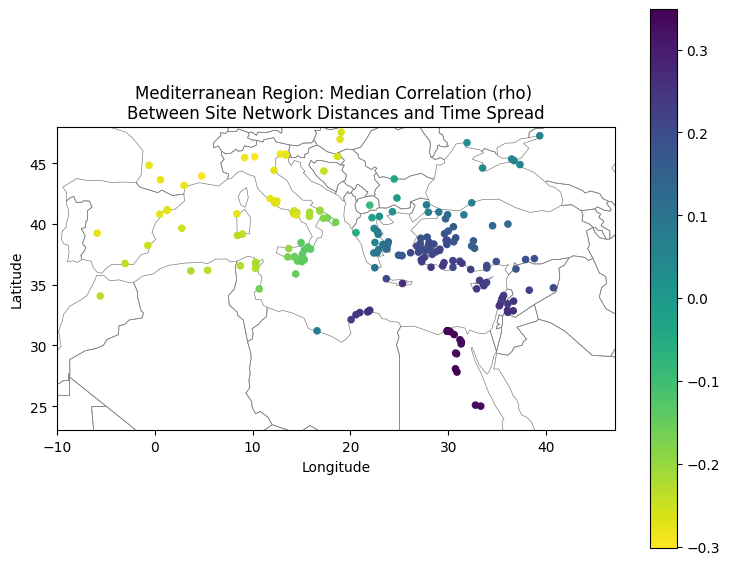

In [ ]:
## plot site as origin probabilities

gdf3 = gpd.GeoDataFrame(
    df_locations,
    geometry=gpd.points_from_xy(df_locations['long'], df_locations['lat']),
    crs='EPSG:4326'
)


fig, ax = plt.subplots(figsize=(9, 7))

# country outlines only
world_med.plot(
    ax=ax,
    color="none",
    edgecolor="grey",
    linewidth=0.5
)

#  points
gdf3.plot(
    ax=ax,
    markersize=20,
    column='rho_median',
    cmap='viridis_r',
    #alpha=0.4,
    legend=True
)

# also plot rotated pca axes
# PCA axes

scale = 20
direction = [1,1]
# if model_rot.params['med_axis'] == abs(model_rot.params['med_axis']):
#   direction[0] = -1
# if model_rot.params['med_orth'] == abs(model_rot.params['med_orth']):
#   direction[0] = -1


ax.set_xlim(med_bounds["minx"], med_bounds["maxx"])
ax.set_ylim(med_bounds["miny"], med_bounds["maxy"])

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title("Mediterranean Region: Median Correlation (rho) \nBetween Site Network Distances and Time Spread")

plt.show()

## Plot the longitude (raw or rotated) of inscription graph center by century

In [ ]:
# revise for consistency and move up
cent_columns = ['pre II', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']
cent_weights = [50, 150, 250, 350, 450, 550, 650, 750]
Y_observed = df_locations[cent_columns].copy()
insc_idx = df_jewish['idx']
site_idx_order = df_locations.index.to_list()
pair_costs = inscr_pairs.set_index('pairs')['km'].to_dict()

In [ ]:
def site_visibility_matrix(df_inscr, century_cols):
    """
    Compute probability that each site has at least one inscription
    visible by each century.

    Parameters
    ----------
    df_inscr : pd.DataFrame
        Inscription level data with 'idx' and century_cols
    century_cols : list
        Ordered century column names

    Returns
    -------
    pd.DataFrame: shape (n_sites, n_centuries)
        Values in [0, 1] representing site visibility probability
        Index = site idx
    """
    # Cumulative probability per inscription that it dates to <= century t
    # shape: (n_inscriptions, n_centuries)
    insc_cumulative = df_inscr[century_cols].cumsum(axis=1)

    # Probability inscription dates LATER than century t
    # = 1 - cumulative probability
    insc_later = 1 - insc_cumulative

    # For each site, probability ALL inscriptions date later than t
    # = product of individual probabilities
    # Take log, sum, exponentiate for numerical stability
    insc_later = insc_later.clip(lower=0)  # guard against float errors < 0

    log_later = np.log(insc_later.replace(0, np.nan))
    log_later['idx'] = df_inscr['idx'].values

    # Sum log probabilities within site
    log_sum = log_later.groupby('idx')[century_cols].sum()

    # P(at least one visible) = 1 - exp(sum of logs)
    # where nan in log_sum means at least one inscription
    # has probability 0 of being later — i.e. site is certainly visible
    p_all_later = np.exp(log_sum)
    p_all_later = p_all_later.fillna(0)  # certain visibility

    site_visibility = 1 - p_all_later

    return site_visibility

In [ ]:
def westward_shift(df_inscr, century_cols, century_dates):
    """
    Track the weighted mean longitude of epigraphic activity
    century by century, using new visibility weight each century.

    Parameters
    ----------
    df_inscr : pd.DataFrame
        Inscription level data with columns:
        'idx', 'Place',
        'long', 'lat',
        'med_axis', 'med_orth' [rotated axes above]
        and century_cols
    century_cols : list of str
        Ordered century column names
    century_dates : list of float
        Midpoint year for each century

    Returns
    -------
    pd.DataFrame with columns:
        century, century_date,
        weighted_mean_long, weighted_mean_lat,
        weighted_mean_axis, weighted_mean_orth,
        n_new_sites, new_weight,
        cumulative_mean_long, cumulative_mean_lat,
        cumulative_mean_axis, cumulative_mean_orth
    """
    # Site-level coordinates — one row per site
    site_coords = df_inscr.groupby('idx')[['long', 'lat','med_axis','med_orth']].first()

    # Site visibility matrix: shape (n_sites, n_centuries)
    # Values in [0,1] — probability site visible by century t
    visibility = site_visibility_matrix(df_inscr, century_cols)

    # Align coordinates with visibility index
    site_coords = site_coords.loc[visibility.index]

    results = []

    for t, (col, date) in enumerate(zip(century_cols, century_dates)):

        # New visibility weight this century
        if t == 0:
            new_weight = visibility[col].clip(lower=0)
        else:
            prev_col = century_cols[t - 1]
            new_weight = (
                visibility[col] - visibility[prev_col]
            ).clip(lower=0)

        # Cumulative visibility weight through this century
        cum_weight = visibility[col]

        # Active new sites
        active_new = new_weight[new_weight > 0]
        active_cum = cum_weight[cum_weight > 0]

        if len(active_new) == 0:
            results.append({
                'century': col,
                'century_date': date,
                'weighted_mean_long': np.nan,
                'weighted_mean_lat': np.nan,
                'weighted_mean_axis': np.nan,
                'weighted_mean_orth': np.nan,
                'n_new_sites': 0,
                'new_weight': 0.0,
                'cumulative_mean_long': np.nan,
                'cumulative_mean_lat': np.nan,
                'cumulative_mean_axis': np.nan,
                'cumulative_mean_orth': np.nan,

                'n_cumulative_sites': 0
            })
            continue

        # Weighted mean longitude and latitude of NEW sites
        new_longs = site_coords.loc[active_new.index, 'long'].values
        new_lats  = site_coords.loc[active_new.index, 'lat'].values
        new_axis = site_coords.loc[active_new.index, 'med_axis'].values
        new_orth  = site_coords.loc[active_new.index, 'med_orth'].values
        new_w     = active_new.values

        weighted_mean_long = (new_w * new_longs).sum() / new_w.sum()
        weighted_mean_lat  = (new_w * new_lats).sum()  / new_w.sum()
        weighted_mean_axis = (new_w * new_axis).sum() / new_w.sum()
        weighted_mean_orth = (new_w * new_orth).sum()  / new_w.sum()

        # Weighted mean longitude and latitude of ALL cumulative sites
        cum_longs = site_coords.loc[active_cum.index, 'long'].values
        cum_lats  = site_coords.loc[active_cum.index, 'lat'].values
        cum_axis = site_coords.loc[active_cum.index, 'med_axis'].values
        cum_orth = site_coords.loc[active_cum.index, 'med_orth'].values
        cum_w     = active_cum.values

        cumulative_mean_long = (cum_w * cum_longs).sum() / cum_w.sum()
        cumulative_mean_lat  = (cum_w * cum_lats).sum()  / cum_w.sum()
        cumulative_mean_axis = (cum_w * cum_axis).sum() / cum_w.sum()
        cumulative_mean_orth  = (cum_w * cum_orth).sum()  / cum_w.sum()

        results.append({
            'century': col,
            'century_date': date,
            'weighted_mean_long': weighted_mean_long,
            'weighted_mean_lat': weighted_mean_lat,
            'weighted_mean_axis': weighted_mean_axis,
            'weighted_mean_orth': weighted_mean_orth,
            'n_new_sites': len(active_new),
            'new_weight': new_w.sum(),
            'cumulative_mean_long': cumulative_mean_long,
            'cumulative_mean_lat': cumulative_mean_lat,
            'cumulative_mean_axis': cumulative_mean_axis,
            'cumulative_mean_orth': cumulative_mean_orth,
            'n_cumulative_sites': len(active_cum)
        })

    return pd.DataFrame(results)

In [ ]:
df_westward_shift = westward_shift(df_jewish,cent_columns, cent_weights)

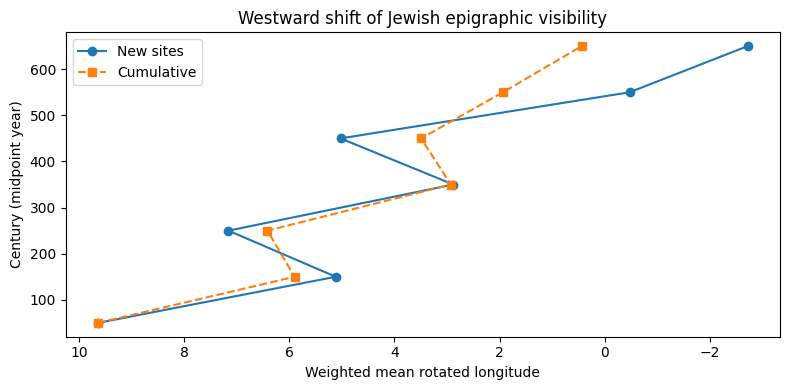

In [ ]:
df_shift = westward_shift(df_jewish, cent_columns, cent_weights)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_shift['weighted_mean_axis'],
        df_shift['century_date'],
        marker='o', label='New sites')
ax.plot(df_shift['cumulative_mean_axis'],
        df_shift['century_date'],
        marker='s', linestyle='--', label='Cumulative')

ax.set_ylabel('Century (midpoint year)')
ax.set_xlabel('Weighted mean rotated longitude')
ax.set_title('Westward shift of Jewish epigraphic visibility')
ax.legend()
ax.invert_xaxis()  # optional: west at top
plt.tight_layout()

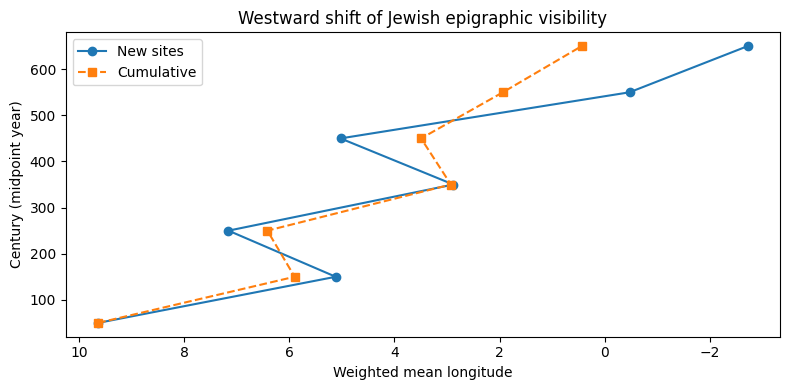

In [ ]:
df_shift = westward_shift(df_jewish, cent_columns, cent_weights)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_shift['weighted_mean_axis'],
        df_shift['century_date'],
        marker='o', label='New sites')
ax.plot(df_shift['cumulative_mean_axis'],
        df_shift['century_date'],
        marker='s', linestyle='--', label='Cumulative')

ax.set_ylabel('Century (midpoint year)')
ax.set_xlabel('Weighted mean longitude')
ax.set_title('Westward shift of Jewish epigraphic visibility')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()

## Observations
Distance between sites is positively correlated with time span between them. Although Spearman's rho is not sensitive to direction, plotting the median or mean rho of each site on the map shows a clear westward gradiant. Roughly speaking this fits with a propagation of sites across the Mediterranean from east to West.

Tracing the center of the graph as sites are added each century, similarly suggests westward movement. Results on raw or rotated longitude are more or less indistingusishable. Tracing the East-West position of the graph by century shows a westward trend (although not monotonic). Restricting the plot to sites that are added each century (`new sites`) shows much the same pattern, with a  pronounced Western shift for (the admittedly very few) new sites in the sixth and seventh centuries.